# Genetic Algorithm for University Timetable Optimization

This notebook walks through every stage of the Constraint-Aware Genetic
Algorithm used by the backend, importing the **same core optimizer code**
that the FastAPI service uses (`backend/optimizer/`) — there is only one
GA implementation in this project, not a separate notebook version.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import random

from backend.data.sample_data import build_sample_dataset
from backend.models.schemas import GAConfig
from backend.optimizer.chromosome import ProblemContext, create_initial_population, create_random_chromosome
from backend.optimizer.fitness import evaluate
from backend.optimizer.operators import tournament_selection, two_point_crossover, mutate, repair
from backend.optimizer.ga import run_ga
import matplotlib.pyplot as plt


## 1. Problem Statement

University timetabling is a **combinatorial optimization problem**: we must
assign every required (subject, faculty, batch) session to a (room, day,
period) slot, subject to hard constraints (no faculty/room/batch double
booking, sufficient room capacity) while minimizing soft-constraint costs
(idle gaps, uneven distribution).

The search space is discrete and the objective is not differentiable, so
**gradient descent is not applicable**. A Genetic Algorithm searches the
discrete space for a high-quality *feasible* solution — it does not claim to
guarantee the global optimum.

## 2. Sample Dataset

In [2]:
dataset = build_sample_dataset()
print(f"Subjects: {len(dataset.subjects)}")
print(f"Faculty:  {len(dataset.faculty)}")
print(f"Rooms:    {len(dataset.rooms)}")
print(f"Batches:  {len(dataset.batches)}")
total_sessions = sum(s.sessions_per_week for s in dataset.subjects)
print(f"Total required sessions/week: {total_sessions}")
dataset.subjects[:5]


Subjects: 30
Faculty:  20
Rooms:    10
Batches:  5
Total required sessions/week: 90


[Subject(subject_id='S01', name='Artificial Intelligence', faculty_id='F01', batch_id='B1', sessions_per_week=3, expected_students=45, preferred_room_type=None),
 Subject(subject_id='S02', name='Machine Learning', faculty_id='F02', batch_id='B2', sessions_per_week=2, expected_students=50, preferred_room_type='Lab'),
 Subject(subject_id='S03', name='Deep Learning', faculty_id='F03', batch_id='B3', sessions_per_week=4, expected_students=55, preferred_room_type='Lab'),
 Subject(subject_id='S04', name='Database Management Systems', faculty_id='F04', batch_id='B4', sessions_per_week=3, expected_students=60, preferred_room_type=None),
 Subject(subject_id='S05', name='Operating Systems', faculty_id='F05', batch_id='B5', sessions_per_week=2, expected_students=65, preferred_room_type=None)]

## 3. Chromosome Representation

A **gene** is one scheduled session: `(subject_id, faculty_id, batch_id, room_id, day, period)`.
A **chromosome** is the full ordered list of genes for every required session — one complete
candidate timetable. A **population** is a set of candidate timetables.

In [3]:
ctx = ProblemContext.build(dataset)
rng = random.Random(42)
sample_chromosome = create_random_chromosome(ctx, rng)
print(f"Chromosome length (genes): {len(sample_chromosome)}")
sample_chromosome[:5]


Chromosome length (genes): 90


[Gene(subject_id='S01', faculty_id='F01', batch_id='B1', room_id='R09', day='Mon', period=1),
 Gene(subject_id='S01', faculty_id='F01', batch_id='B1', room_id='R09', day='Wed', period=2),
 Gene(subject_id='S01', faculty_id='F01', batch_id='B1', room_id='R03', day='Tue', period=6),
 Gene(subject_id='S02', faculty_id='F02', batch_id='B2', room_id='R01', day='Fri', period=1),
 Gene(subject_id='S02', faculty_id='F02', batch_id='B2', room_id='R07', day='Thu', period=1)]

## 4. Fitness / Cost Function

In [4]:
config = GAConfig(population_size=80, generations=150, random_seed=42, stagnation_limit=40)
cost, fitness, counts = evaluate(sample_chromosome, ctx, config)
print(f"Cost: {cost:.1f}  Fitness: {fitness:.6f}")
print(counts)


Cost: 44615.0  Fitness: 0.000022
ConstraintCounts(faculty_conflicts=7, student_conflicts=22, room_conflicts=15, capacity_violations=0, faculty_gaps=22, student_gaps=32, distribution_penalty_units=15)


## 5. Initial Population

In [5]:
population = create_initial_population(ctx, 10, rng)
print(f"Population size: {len(population)}")
for i, chromo in enumerate(population[:3]):
    c, f, cn = evaluate(chromo, ctx, config)
    print(f"  individual {i}: cost={c:.1f} fitness={f:.5f} hard_violations={cn.hard_total}")


Population size: 10
  individual 0: cost=50635.0 fitness=0.00002 hard_violations=50
  individual 1: cost=47650.0 fitness=0.00002 hard_violations=47
  individual 2: cost=36775.0 fitness=0.00003 hard_violations=36


## 6. Hard vs. Soft Constraints

**Hard constraints** (must ideally become zero): faculty conflicts, room conflicts,
student/batch conflicts, capacity violations.

**Soft constraints** (should be minimized): faculty idle gaps, student/batch idle
gaps, uneven distribution of a subject's sessions across the week.

In [6]:
_, _, counts = evaluate(population[0], ctx, config)
print("HARD  ", "faculty:", counts.faculty_conflicts, "room:", counts.room_conflicts,
      "batch:", counts.student_conflicts, "capacity:", counts.capacity_violations)
print("SOFT  ", "faculty_gaps:", counts.faculty_gaps, "student_gaps:", counts.student_gaps,
      "distribution:", counts.distribution_penalty_units)


HARD   faculty: 9 room: 19 batch: 22 capacity: 0
SOFT   faculty_gaps: 24 student_gaps: 29 distribution: 21


## 7. Tournament Selection

In [7]:
fitnesses = [evaluate(c, ctx, config)[1] for c in population]
parent = tournament_selection(population, fitnesses, tournament_size=3, rng=rng)
print(f"Selected parent has {len(parent)} genes; fitness of pool ranged "
      f"{min(fitnesses):.5f} - {max(fitnesses):.5f}")


Selected parent has 90 genes; fitness of pool ranged 0.00002 - 0.00003


## 8. Crossover

Two-point crossover swaps a segment of (room, day, period) assignments
between two parents. The subject/faculty/batch identity of each gene is
never touched by crossover, so every required session is still present —
crossover can only introduce *slot* conflicts, which the repair stage
then resolves.

In [8]:
child_a, child_b = two_point_crossover(population[0], population[1], rng)
print(f"child_a length: {len(child_a)} (matches parent: {len(child_a) == len(population[0])})")


child_a length: 90 (matches parent: True)


## 9. Mutation

In [9]:
before = [(g.day, g.period, g.room_id) for g in child_a]
mutate(child_a, ctx, mutation_rate=config.mutation_rate, rng=rng)
after = [(g.day, g.period, g.room_id) for g in child_a]
changed = sum(1 for b, a in zip(before, after) if b != a)
print(f"Genes mutated: {changed} / {len(child_a)}")


Genes mutated: 17 / 90


## 10. Constraint Repair

In [10]:
_, _, before_counts = evaluate(child_a, ctx, config)
repair(child_a, ctx, rng)
_, _, after_counts = evaluate(child_a, ctx, config)
print(f"Hard violations before repair: {before_counts.hard_total}")
print(f"Hard violations after repair:  {after_counts.hard_total}")


Hard violations before repair: 57
Hard violations after repair:  3


## 11. Elitism

Elitism copies the best `elite_count` individuals unchanged into the next
generation, so the best solution found so far can never be lost to
crossover or mutation.

## 12. Complete GA — Running the Full Pipeline

In [11]:
result = run_ga(dataset, config)
print(f"Generations executed: {result.generations_executed}")
print(f"Converged early: {result.converged_early}")
print(f"Best cost: {result.best_cost:.1f}  Best fitness: {result.best_fitness:.6f}")
print(f"Execution time: {result.execution_time_seconds:.2f}s")
print(result.best_counts)


Generations executed: 63
Converged early: True
Best cost: 300.0  Best fitness: 0.003322
Execution time: 2.28s
ConstraintCounts(faculty_conflicts=0, student_conflicts=0, room_conflicts=0, capacity_violations=0, faculty_gaps=10, student_gaps=13, distribution_penalty_units=14)


## 13. Fitness Convergence Graph

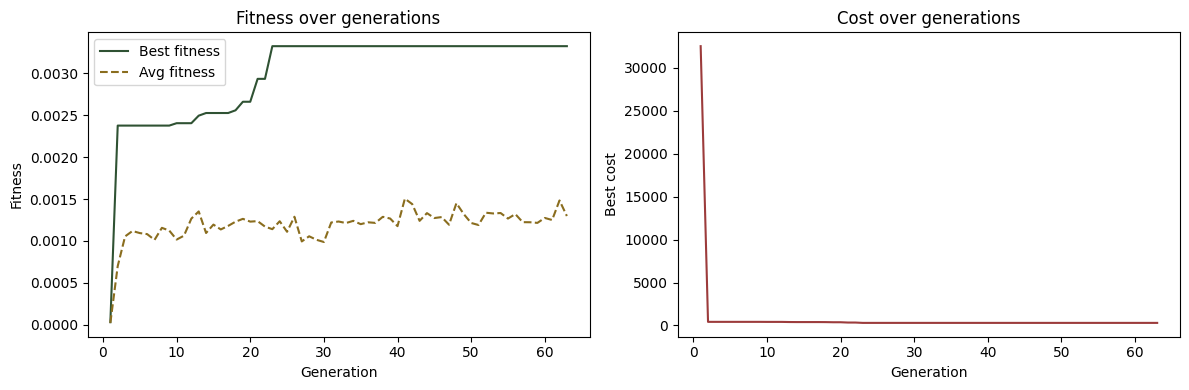

In [12]:
gens = [h.generation for h in result.history]
best_fit = [h.best_fitness for h in result.history]
avg_fit = [h.avg_fitness for h in result.history]
best_cost = [h.best_cost for h in result.history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(gens, best_fit, label="Best fitness", color="#2f5233")
ax1.plot(gens, avg_fit, label="Avg fitness", color="#8a6d1e", linestyle="--")
ax1.set_xlabel("Generation"); ax1.set_ylabel("Fitness"); ax1.legend(); ax1.set_title("Fitness over generations")

ax2.plot(gens, best_cost, color="#9c3b3b")
ax2.set_xlabel("Generation"); ax2.set_ylabel("Best cost"); ax2.set_title("Cost over generations")
plt.tight_layout()
plt.show()


## 14. Final Timetable (first 15 sessions)

In [13]:
ctx2 = result.context
rows = []
for gene in result.best_chromosome[:15]:
    subj = ctx2.subject_by_id[gene.subject_id]
    fac = ctx2.faculty_by_id[gene.faculty_id]
    batch = ctx2.batch_by_id[gene.batch_id]
    room = ctx2.room_by_id[gene.room_id]
    rows.append((gene.day, gene.period, subj.name, fac.name, batch.name, room.room_number))

import pandas as pd
pd.DataFrame(rows, columns=["Day", "Period", "Subject", "Faculty", "Batch", "Room"]).sort_values(["Day", "Period"])


,Day,Period,Subject,Faculty,Batch,Room
3,Fri,2,Machine Learning,Dr. B. Mehta,AIML-B,LT-1
8,Fri,4,Deep Learning,Dr. C. Rao,CSE-A,LT-4
0,Mon,3,Artificial Intelligence,Dr. A. Sharma,AIML-A,LT-10
10,Mon,4,Database Management Systems,Dr. D. Iyer,CSE-B,SR-3
9,Mon,6,Database Management Systems,Dr. D. Iyer,CSE-B,SR-3
14,Thu,1,Computer Networks,Dr. F. Kapoor,AIML-A,SR-9
7,Thu,2,Deep Learning,Dr. C. Rao,CSE-A,LT-4
11,Thu,2,Database Management Systems,Dr. D. Iyer,CSE-B,SR-9
5,Thu,3,Deep Learning,Dr. C. Rao,CSE-A,LT-10
1,Thu,5,Artificial Intelligence,Dr. A. Sharma,AIML-A,LT-4


## 15. Constraint Analysis of the Final Solution

In [14]:
c = result.best_counts
print("HARD CONSTRAINTS (should be 0):")
print(f"  Faculty conflicts:    {c.faculty_conflicts}")
print(f"  Room conflicts:       {c.room_conflicts}")
print(f"  Batch conflicts:      {c.student_conflicts}")
print(f"  Capacity violations:  {c.capacity_violations}")
print("SOFT CONSTRAINTS (minimized, not required to be 0):")
print(f"  Faculty idle gaps:    {c.faculty_gaps}")
print(f"  Student idle gaps:    {c.student_gaps}")
print(f"  Distribution penalty: {c.distribution_penalty_units}")


HARD CONSTRAINTS (should be 0):
  Faculty conflicts:    0
  Room conflicts:       0
  Batch conflicts:      0
  Capacity violations:  0
SOFT CONSTRAINTS (minimized, not required to be 0):
  Faculty idle gaps:    10
  Student idle gaps:    13
  Distribution penalty: 14


## 16. Conclusion

The Genetic Algorithm converged to a timetable with **zero hard-constraint
violations** — every faculty member, room, and student batch has a
conflict-free schedule with sufficient room capacity — while minimizing
soft-constraint costs (idle gaps and uneven distribution). This is the
same optimizer the FastAPI backend runs behind `/api/optimize`, so the
result shown in the web UI is produced by exactly this pipeline.